In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pandas as pd
df = pd.read_csv("Road Accident Data.csv")

In [4]:
print("\n--- Initial Assessment ---")
print(f"Data Shape: {df.shape}")
print(f"Total Duplicates: {df.duplicated().sum()}")
print("\n--- Missing Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])


--- Initial Assessment ---
Data Shape: (307973, 23)
Total Duplicates: 1

--- Missing Values ---
Carriageway_Hazards        302549
Road_Surface_Conditions       317
Road_Type                    1534
Time                           17
Weather_Conditions           6057
dtype: int64


In [5]:
print("\n--- Numerical Summary Statistics ---")
print(df.describe())


--- Numerical Summary Statistics ---
                Year       Latitude      Longitude  Number_of_Casualties  \
count  307973.000000  307973.000000  307973.000000         307973.000000   
mean     2021.468934      52.487005      -1.368884              1.356882   
std         0.499035       1.339011       1.356092              0.815857   
min      2021.000000      49.914488      -7.516225              1.000000   
25%      2021.000000      51.485248      -2.247937              1.000000   
50%      2021.000000      52.225943      -1.349258              1.000000   
75%      2022.000000      53.415517      -0.206810              1.000000   
max      2022.000000      60.598055       1.759398             48.000000   

       Number_of_Vehicles    Speed_limit  
count       307973.000000  307973.000000  
mean             1.829063      38.866037  
std              0.710477      14.032933  
min              1.000000      10.000000  
25%              1.000000      30.000000  
50%              2.

In [6]:
print("\n--- Categorical Summary Statistics ---")
print(df.describe(include=['object']))


--- Categorical Summary Statistics ---
       Accident_Index Accident Date   Month Day_of_Week  \
count          307973        307973  307973      307973   
unique         197644           730      12           7   
top          2.01E+12      13-11-21     Nov      Friday   
freq           110304           692   29095       50529   

                Junction_Control                      Junction_Detail  \
count                     307973                               307973   
unique                         6                                    9   
top     Give way or uncontrolled  Not at junction or within 20 metres   
freq                      150045                               123094   

       Accident_Severity Light_Conditions Local_Authority_(District)  \
count             307973           307973                     307973   
unique                 3                5                        422   
top               Slight         Daylight                 Birmingham   
freq      

In [7]:
# ==========================================
# Phase 3: Data Cleaning
# ==========================================
print("\nCleaning data...")
# 1. Remove Duplicates
df.drop_duplicates(inplace=True)


Cleaning data...


In [8]:
# 2. Handle Missing Values
# Carriageway_Hazards has ~302k missing values, assume 'None'
df['Carriageway_Hazards'] = df['Carriageway_Hazards'].fillna('None')

In [9]:
# Impute mode for missing categorical/time variables
cols_to_fill = ['Road_Surface_Conditions', 'Road_Type', 'Weather_Conditions', 'Time']
for col in cols_to_fill:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# ==========================================
# Phase 4: Feature Engineering
# ==========================================
print("Engineering new features...")

Engineering new features...


In [11]:
# 1. Parse Dates and Time
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce', dayfirst=True)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour

/tmp/ipython-input-449/3631885649.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors='coerce', dayfirst=True)


In [12]:
# 2. Weekend vs Weekday Flag
df['Is_Weekend'] = df['Day_of_Week'].isin(['Saturday', 'Sunday']).astype(int)

In [13]:
# 3. Time of Day Categorization
def get_time_of_day(hour):
    if pd.isna(hour): return 'Unknown'
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df['Time_of_Day'] = df['Hour'].apply(get_time_of_day)

In [14]:
# ==========================================
# Phase 5: Advanced Exploratory Data Analysis (EDA)
# ==========================================
print("Generating Advanced EDA plots...")
sns.set_theme(style="whitegrid")

Generating Advanced EDA plots...


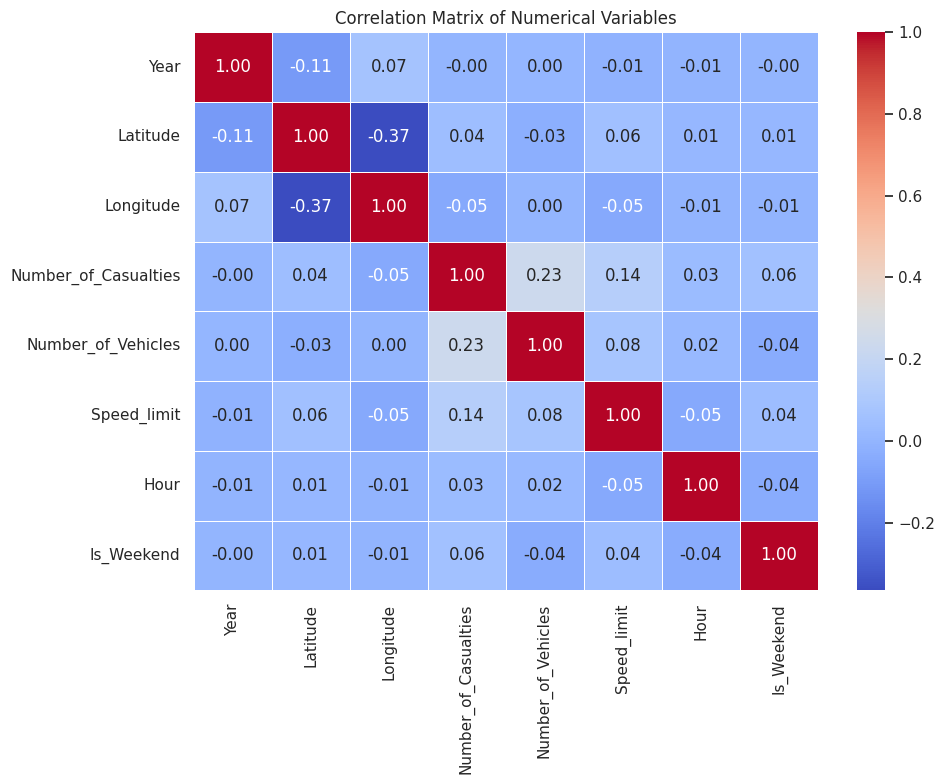

In [15]:
# Plot 1: Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

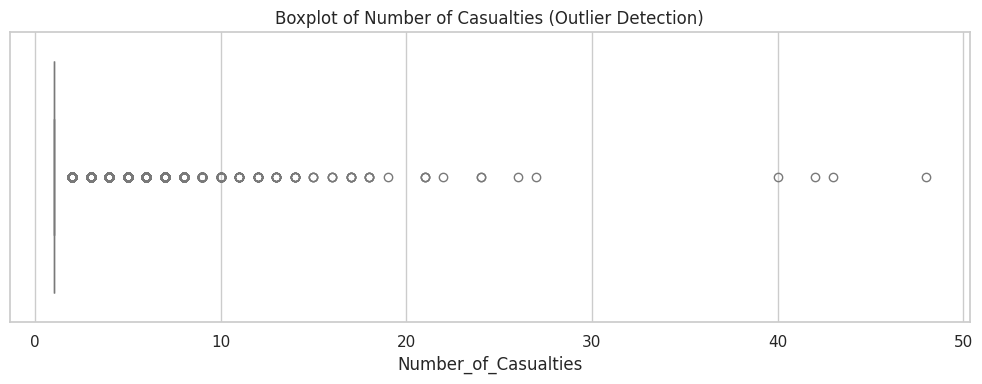

In [16]:
# Plot 2: Boxplot for Outliers Detection (Number of Casualties)
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Number_of_Casualties'], color='lightblue')
plt.title("Boxplot of Number of Casualties (Outlier Detection)")
plt.tight_layout()
plt.show()

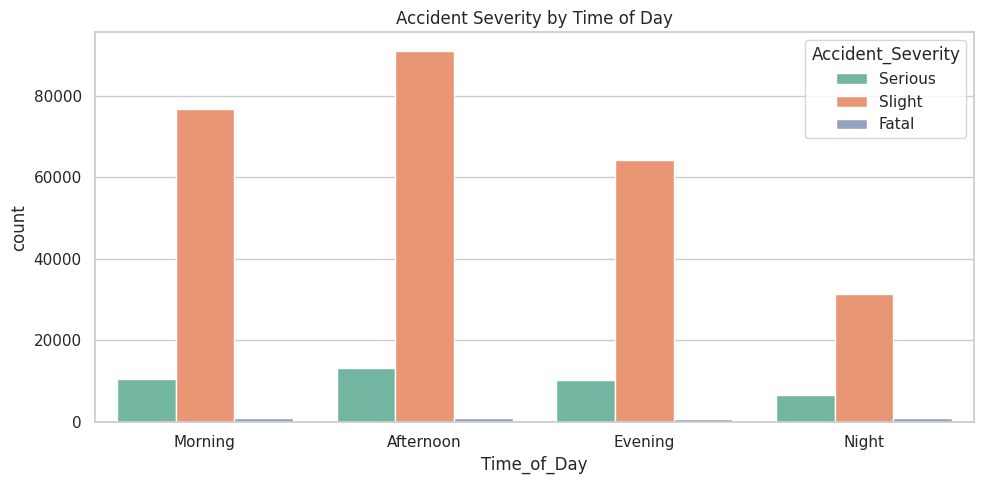

In [17]:
# Plot 3: Multivariate Analysis - Severity vs Time of Day
plt.figure(figsize=(10, 5))
sns.countplot(x='Time_of_Day', hue='Accident_Severity', data=df, palette='Set2',
              order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Accident Severity by Time of Day')
plt.tight_layout()
plt.show()

In [18]:
# ==========================================
# Phase 6: Exporting Final Cleaned Data
# ==========================================
print("Saving cleaned data...")
df.to_csv('Final_Complete_Project_Data.csv', index=False)
print("Project Execution Completed Successfully!")

Saving cleaned data...
Project Execution Completed Successfully!
